Here just show the case of iST-SVC; see the [other reproduced notebooks](./) in this directory for further real applications.

In [1]:
import os

output_dir = "../../output/sc_SVC_case"
raw_data_dir = "../../raw_data/Real_application"

patient_id = "P2CRC"
data_type = "Xenium"
output_dir = f"{output_dir}/{patient_id}_{data_type}"
sc_ref_file="adata_sc_all_reanno.h5ad"

cell_type_col = "Level1"

In [2]:
select_ct = "T"
output_dir = f"{output_dir}/{select_ct}"
os.makedirs(output_dir, exist_ok=True)

In [ ]:
from revise.config.runner_conf import ApplicationScConf

config = ApplicationScConf(
    sample_name=patient_id,
    raw_data_path=raw_data_dir,
    result_root_path=output_dir,
    cell_type_col=cell_type_col,
    confidence_col="Confidence",
    unknown_key="Unknown",
    st_file=f"{data_type}.h5ad",
    sc_ref_file=sc_ref_file,
    annotate_mode="pot"
)

In [4]:
import scanpy as sc

adata_st = sc.read_h5ad(config.st_file_path)

adata_sc_ref = sc.read_h5ad(config.sc_ref_file_path)
adata_sc_ref = adata_sc_ref[adata_sc_ref.obs['Patient'] == patient_id, :]

In [ ]:
from revise.backend.kernels import GlobalAnchoringKernel
from revise.backend.runners.sc_svc_application import ScSVC
from revise.utils.logging import Logger

logger = Logger(name=f"run.log", log_file=f'{output_dir}/application_sc.log').get_logger()
sc_svc = ScSVC(adata_st, adata_sc_ref, config, logger)
annotate_method = GlobalAnchoringKernel(config, logger)
adata_st = annotate_method.run(sc_svc.st_adata, sc_svc.sc_ref_adata, **config.__dict__)

In [6]:
print(select_ct)
ct_adata_sc = sc_svc.sc_ref_adata[sc_svc.sc_ref_adata.obs[cell_type_col] == select_ct]
ct_adata_sp = adata_st[adata_st.obs[cell_type_col] == select_ct]

T


In [ ]:
subcell_type_col = "Level2"
subcell_kwargs = dict(config.__dict__)
subcell_kwargs["cell_type_col"] = subcell_type_col
ct_adata_sp = annotate_method.run(ct_adata_sp, ct_adata_sc, **subcell_kwargs)

sp Finial gene number: 200


/inspire/ssd/tenant_predefaa-9a1b-4522-bb10-8850f313be13/global_user/5307-jiaoyifeng/miniconda3/envs/revise/lib/python3.11/site-packages/scanpy/preprocessing/_pca/__init__.py:384: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = x_pca


Setting joint graph with alpha = 0.2


leiden:   0%|          | 0/3 [00:00<?, ?it/s][2025-12-08 09:09:57] [INFO] [graph_cluster.py:69] Resolution 0.6: 6 clusters mean spatial score: 2.4440 0.7903...


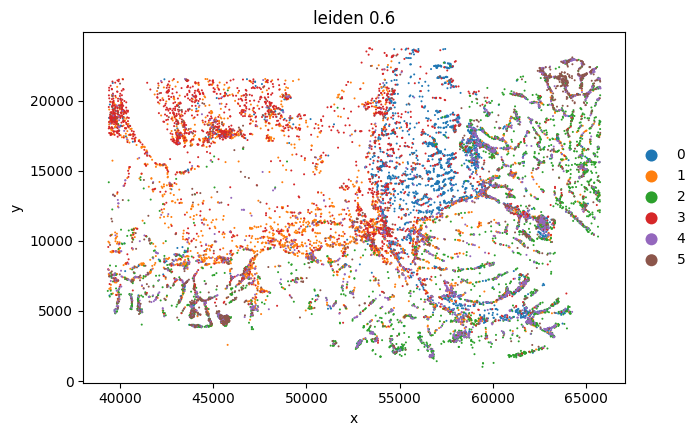

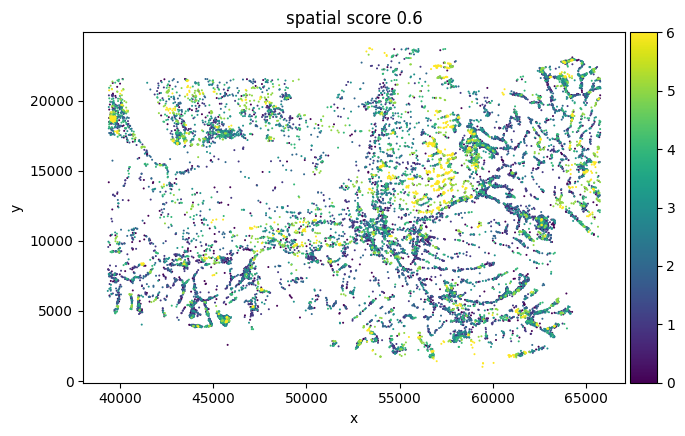

leiden:  33%|███▎      | 1/3 [00:19<00:39, 19.52s/it][2025-12-08 09:10:12] [INFO] [graph_cluster.py:69] Resolution 0.7: 7 clusters mean spatial score: 2.3287 0.779...


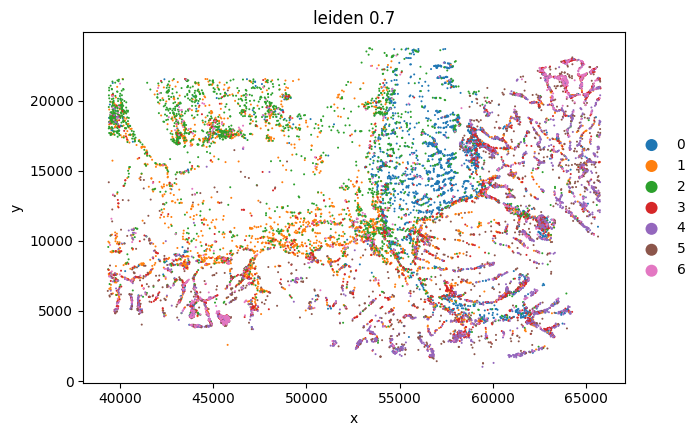

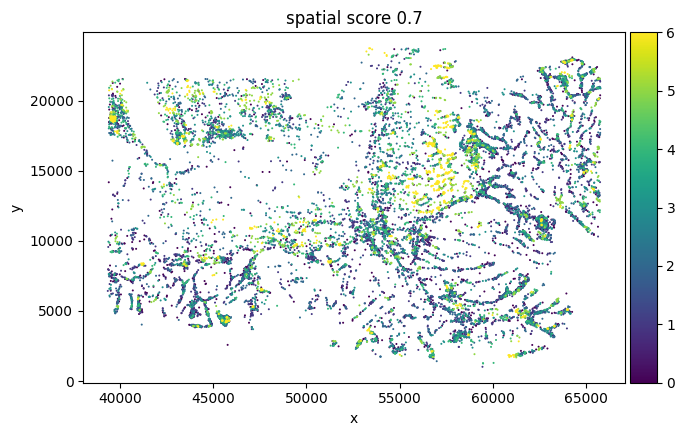

leiden:  67%|██████▋   | 2/3 [00:34<00:16, 16.93s/it][2025-12-08 09:10:29] [INFO] [graph_cluster.py:69] Resolution 0.8: 8 clusters mean spatial score: 2.5752 0.724...


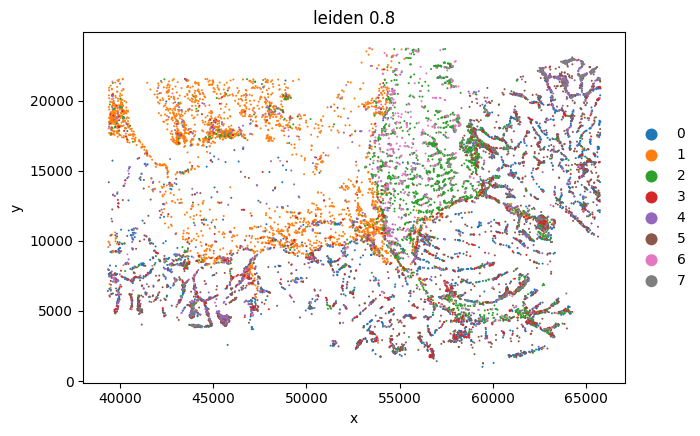

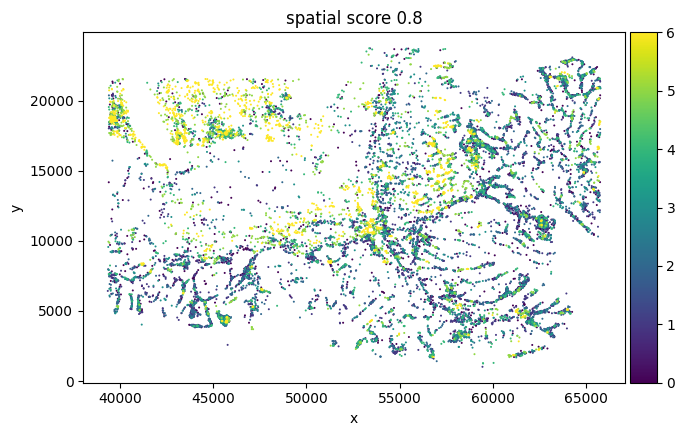

leiden: 100%|██████████| 3/3 [00:51<00:00, 17.32s/it]
[2025-12-08 09:10:29] [INFO] [graph_cluster.py:74] Best resolution: 0.6


AnnData object with n_obs × n_vars = 14219 × 343
    obs: 'cell_id', 'x', 'y', 'transcript_counts', 'control_probe_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'x_old', 'y_old', 'Level1', 'max_score', 'Confidence', 'Level2', 'leiden_0.6', 'spatial_score_0.6', 'leiden_0.7', 'spatial_score_0.7', 'leiden_0.8', 'spatial_score_0.8'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    obsm: 'Level1', 'spatial', 'Level2'

In [ ]:
from revise.backend.kernels import GraphClusterKernel

# resolutions = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
resolutions = [0.6, 0.7, 0.8]

graph_cluster = GraphClusterKernel(config, logger)
sc_SVC_adata, merge_df, best_res = graph_cluster.run(ct_adata_sp, resolutions, subcell_type_col)

sc_SVC_adata

In [10]:
sc_SVC_adata.obs['SVC_cluster'] = sc_SVC_adata.obs[f'leiden_{best_res}']
sp_cluster_num = merge_df.loc[merge_df['resolution'] == best_res, 'cluster_num'].values[0]
sp_cluster_num

np.int64(6)

In [ ]:
cluster_kwargs = dict(config.__dict__)
cluster_kwargs["cell_type_col"] = "SVC_cluster"
ct_adata_sc = annotate_method.run(ct_adata_sc, sc_SVC_adata, **cluster_kwargs)
ct_adata_sc

In [12]:
sc_SVC_adata.write(f"{output_dir}/sc_SVC_spatial.h5ad")
ct_adata_sc.write(f"{output_dir}/sc_SVC_expr.h5ad")

In [13]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def get_cm(adata, row, col):
    grouped = adata.obs.groupby([row, col]).size()
    cm_df = grouped.unstack(fill_value=0)
    
    return cm_df
def plot_cm(cm_df, save_dir=None):
    
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(cm_df, 
                    annot=True, 
                    fmt='',
                    cmap='Reds',
                    )

    
    plt.title('Confusion Matrix')
    plt.xlabel('Expert anno')
    plt.ylabel('sc_SVC cluster')
    
    if save_dir is not None:
        plt.savefig(f"{save_dir}/cm.pdf", bbox_inches='tight')
        plt.close()
    else:
        plt.show()


In [14]:
cm_df = get_cm(ct_adata_sc, 'SVC_cluster', subcell_type_col)
plot_cm(cm_df, save_dir = output_dir)
cm_df

/tmp/ipykernel_879235/1622614457.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = adata.obs.groupby([row, col]).size()


Level2,CD4T,CD8T,NK,Tprolif
SVC_cluster,,,,
0,1589,43,0,36
1,609,77,0,13
2,451,17,2,20
3,175,1022,61,43
4,37,3,0,281
5,104,186,90,105


/tmp/ipykernel_879235/3248995108.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', lut=10


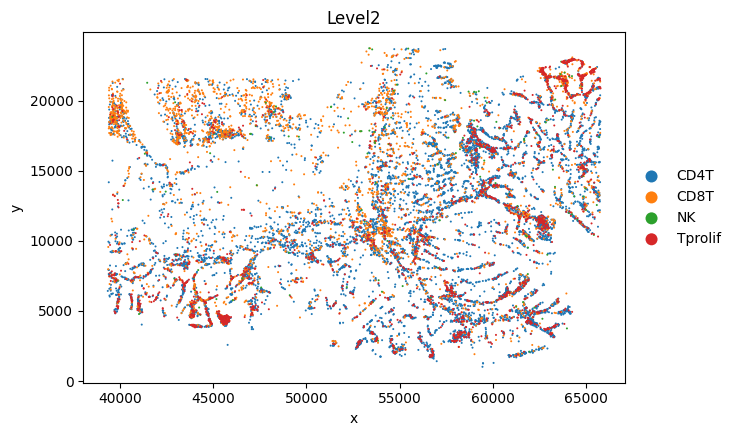

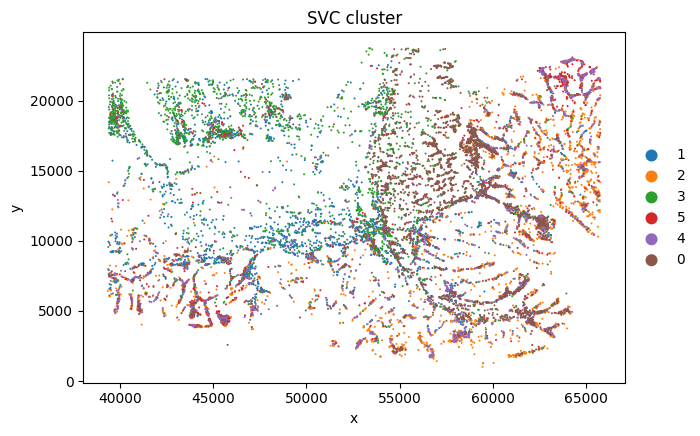

In [15]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors 

size = None
# size = 20
cmap = plt.cm.get_cmap('tab20', lut=10
                  )
palette = [mcolors.to_hex(cmap(i)) for i in range(cmap.N)]

sc.pl.scatter(sc_SVC_adata, x="x", y="y", 
              color = 'Level2',
              # palette=palette,
            size = size
            )
desired_order = ['1','2','3','5','4','0'] # for better visualization
sc_SVC_adata.obs['SVC_cluster'] = (
    sc_SVC_adata.obs['SVC_cluster']
         .cat
         .reorder_categories(desired_order, ordered=True)   # ordered=True 可选
)

sc.pl.scatter(sc_SVC_adata, x="x", y="y", 
              color = 'SVC_cluster',
              # palette=palette,
            size = size
            )

In [16]:
import matplotlib.pyplot as plt
def plot_sc_SVC(adata, color, title = None, file_name = None):

    plt.figure(figsize=(10, 8*len(color)))
    sc.pl.scatter(adata, x="x", y="y", 
            color = color,
            title=title, show = False,
            )
    plt.savefig(file_name, dpi = 300)
    plt.close()
    

sc_SVC_file_name = f"{output_dir}/sc_SVC.png"
plot_sc_SVC(sc_SVC_adata, color = 'SVC_cluster',
            file_name = sc_SVC_file_name
            )

sc_SVC_file_name = f"{output_dir}/compare_Level2.png"
plot_sc_SVC(sc_SVC_adata, color = 'Level2',
            title="Expert anno",
            file_name = sc_SVC_file_name
            )

plot_sc_SVC(sc_SVC_adata, color = 'SVC_cluster',
            title="sc_SVC",
            file_name = sc_SVC_file_name
            )


<Figure size 1000x8800 with 0 Axes>

<Figure size 1000x4800 with 0 Axes>

<Figure size 1000x8800 with 0 Axes>